# `lit-modelreg` — the seam is transferred, never detected

**One of seven methods** in the Phase 4 comparison, and the **top rung of the oracle
ladder**, held by a real published method. Source:

> Weihua Fang, Xincheng Tian.
> *A novel model-based welding trajectory planning method for identical structural
> workpieces.* **RCIM 89 (2024) 102772.**

| stage | here |
|---|---|
| §3.1 the basic model: seam trajectory P, auxiliary trajectory P′ (15 mm along the bisector), edge feature set W | `build_model` — rebuilt from `scene.json` |
| §3.2 Bayesian CPD registration of Y = P ∪ W onto the target's feature set X | `cpd_similarity` + `cpd_nonrigid` (classical CPD; the Bayesian priors are a robustness refinement, not a different mechanism) |
| §3.3 the fitted mapping carries P onto the target | `detect` |
| §3.4 torch pose from P and P′ | carried, unscored |

## The plan's open item, resolved in code

*"Verify `lit-modelreg` is implementable without the original CAD assets; if not, it
becomes an L0 upper bound computed from generator transforms rather than a
reimplementation, and must be labelled as such."* Both halves are true at once:
**implementable** — `scene.json` (dims, `T_world_part`, `T_world_joint`) is a sufficient
CAD source, verified by a test that overlays the rebuilt model on the scan and roundtrips
the seam to 1e-9 — **and constitutively L0-with-CAD**, because the model's seam IS the
stored truth. Every number below carries that label.

## Three findings from building it, each caught by measurement

1. **σ² must start from nearest-neighbour residuals, not the all-pairs mean.** The
   all-pairs mean is ~object-size²; the first E-step goes uniform, the centered
   cross-covariance cancels, and the scale collapses to 0,14 — from an initialisation that
   was already within 2,7°.
2. **The paper's edge features are load-bearing, not incidental.** Registering dense
   surfaces lets a lap stack slide ~5 mm along its overlap — faces dominate the
   correspondence mass and only the plate ends resist. §3.1 says W is the point set of
   the workpiece's **edges**; both sides of their registration are model-derived features
   ("identical workpieces"). A scan-only pipeline has no such stage, so it is supplied as
   an **oracle** like every other method's learned stage, with `target_features="dense"`
   as the withheld arm.
3. **Outside the roughly-positioned envelope, near-symmetric assemblies register onto
   their symmetric counterpart.** A flush or stacked pair maps onto itself flipped with a
   residual the surface barely distinguishes, and the seam lands a plate-length away
   (measured: 119 mm on an edge joint). The paper never faces this — its workpieces
   arrive at a workstation — and the same coarse-positioning assumption is already in
   this plan's spine as D26. `init="near"` is the envelope; `init="global"` is the
   finding.

In [1]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import balanced_corpus, prepare, run_matrix
from baselines.lit_modelreg import build_model, detect
from baselines.metrics import matched_path_errors

CORPUS = balanced_corpus("../out/bench", per_type=50)
print({k: len(v) for k, v in CORPUS.items()})

def view3d(ax, cloud_pts, gt, pred_polys, extras=(), zoom=1.0, centre="cloud",
           elev=24, azim=-60, cloud_step=None):
    """One 3D panel in the house style: grey cloud, green truth, red prediction.

    `extras` is a list of (points, kwargs) scatter layers - planes, feature corridors,
    registered models. `zoom` < 1 closes in on `centre` ("cloud" or "seam").
    """
    import numpy as np
    P = np.asarray(cloud_pts)
    gt_pts = np.vstack(gt) if len(gt) else P
    c0 = gt_pts.mean(0) if centre == "seam" else 0.5 * (P.min(0) + P.max(0))
    half = 0.55 * float((P.max(0) - P.min(0)).max()) * float(zoom)
    step = cloud_step or max(1, len(P) // 6000)
    ax.scatter(*P[::step].T, s=0.4, c="#dcdcdc", depthshade=False)
    for pts_, kw in extras:
        if len(pts_):
            ax.scatter(*np.asarray(pts_).T, **{"s": 4, "alpha": 0.6,
                                               "depthshade": False, **kw})
    for k, g in enumerate(gt):
        ax.plot(*np.asarray(g).T, lw=6, c="#1a7f37", alpha=0.5, zorder=8,
                solid_capstyle="round", label="ground truth" if k == 0 else None)
    for k, s_ in enumerate(pred_polys):
        ax.plot(*np.asarray(s_).T, lw=2.5, c="#d1242f", zorder=12,
                label="prediction" if k == 0 else None)
    for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(c0[i] - half, c0[i] + half)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)
    ax.legend(fontsize=6.5, loc="upper left")

{'T': 50, 'butt': 50, 'corner': 50, 'edge': 50, 'lap': 50}


## One scene, in 3D — the model arriving on the scan

Purple: the model's edge point set at its `init="near"` starting pose. Blue: the same
points after registration. The red seam is not detected anywhere in this figure — it is
the model's own seam, carried through the fitted transform.

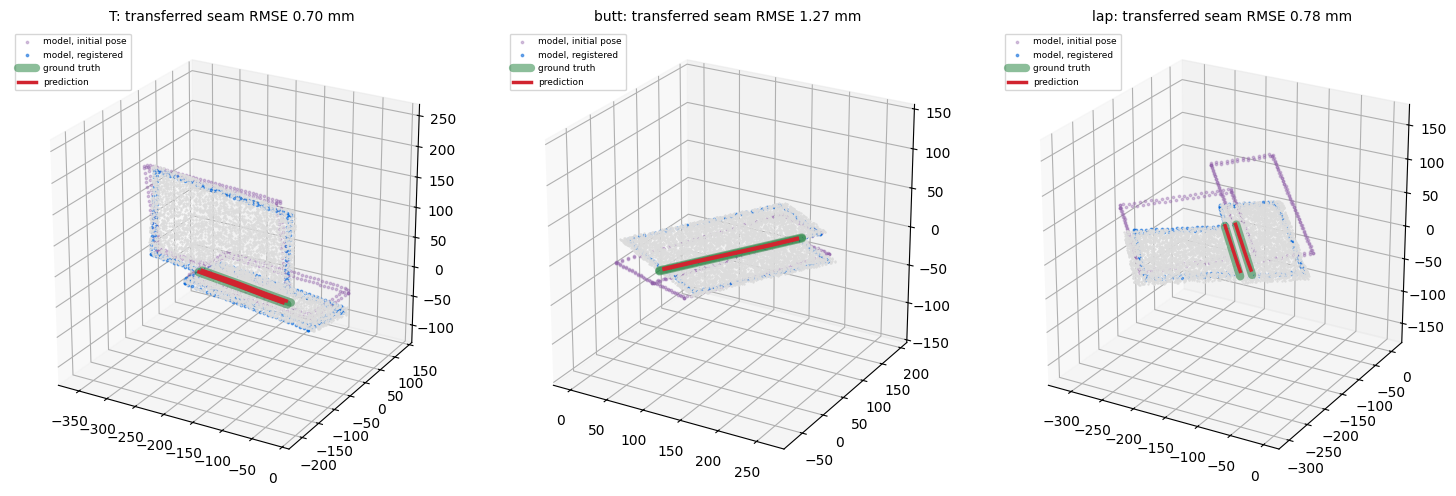

In [2]:
ELEV, AZIM = 24, -60
prep3 = prepare(CORPUS["T"][:1] + CORPUS["butt"][:1] + CORPUS["lap"][:1])

fig = plt.figure(figsize=(15, 4.8))
for k, p_ in enumerate(prep3):
    c = p_.cloud("full", 0.0)
    r = detect(c["xyz"], p_.scene, p_.gt)
    from baselines.lit_modelreg import _near_init_pose, build_model as bm
    Wm, _, _ = bm(p_.scene, p_.gt, edges_only=True)
    T0 = _near_init_pose(p_.scene, 10.0, 20.0)
    start = Wm @ T0[:3, :3].T + T0[:3, 3]
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    view3d(ax, c["xyz"], p_.gt, r.polylines,
           extras=[(start[::2], {"c": "#8f5fa8", "s": 3, "alpha": 0.35,
                                 "label": "model, initial pose"}),
                   (r.model_points[::2], {"c": "#0969da", "s": 3, "alpha": 0.55,
                                          "label": "model, registered"})],
           elev=ELEV, azim=AZIM)
    errs = [e["rmse"] for e in matched_path_errors(r.polylines, p_.gt) if e["matched"]]
    ax.set_title(f"{p_.facts['joint_type']}: transferred seam RMSE "
                 f"{np.median(errs) if errs else float('nan'):.2f} mm", fontsize=10)
plt.tight_layout(); plt.show()

## The corpus, both arms

`L0-oracle` is the paper's condition — model-derived target features on both sides.
`L0-dense` withholds that stage and registers raw surfaces: the slide failures live there,
and the delta between the columns is what the feature stage is worth.

In [3]:
prep_all = prepare([d for jt in ("T", "corner", "butt", "lap", "edge")
                    for d in CORPUS[jt][:12]])
frames = []
for tf in ("oracle", "dense"):
    d = run_matrix(prep_all, methods=["lit-modelreg"], seeds=range(1), verify_seeds=1,
                   method_kw={"lit-modelreg": {"target_features": tf}})
    d["arm"] = f"L0-{tf}"
    frames.append(d)
corp = pd.concat(frames, ignore_index=True)
corp.groupby(["arm", "joint_type"]).agg(
    prec=("precision", "mean"), rec=("recall", "mean"), f1=("f1", "mean"),
    rmse=("rmse_med", "median"), me=("me_med", "median")).round(3)

prec    rec     f1   rmse      me
arm       joint_type                                    
L0-dense  T           0.745  0.694  0.718  1.916   3.804
          butt        0.101  0.094  0.097  8.393  13.436
          corner      0.783  0.734  0.758  2.094   3.822
          edge        0.234  0.230  0.231  7.586  12.551
          lap         0.263  0.237  0.249  8.292  14.362
L0-oracle T           0.998  0.967  0.982  0.652   1.061
          butt        0.773  0.750  0.761  1.340   2.014
          corner      0.969  0.955  0.962  0.691   1.161
          edge        0.264  0.256  0.260  5.091   5.779
          lap         0.619  0.592  0.605  2.594   3.714

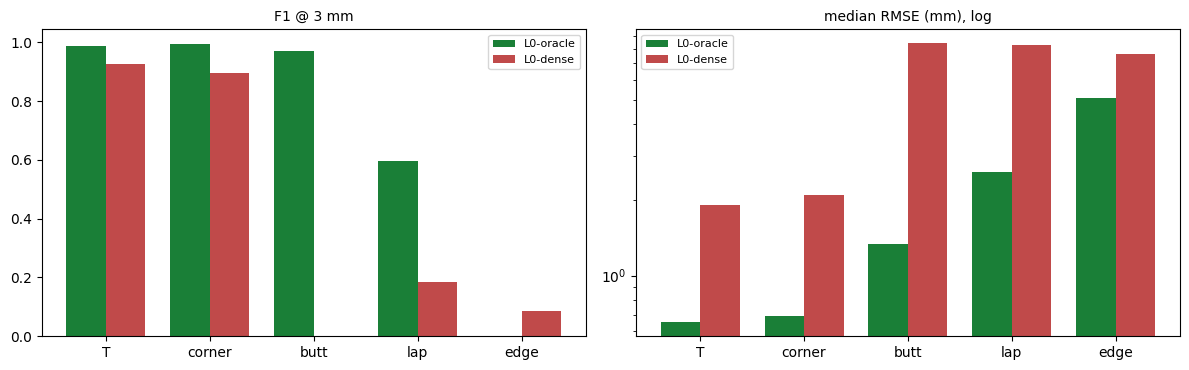

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
order = ["T", "corner", "butt", "lap", "edge"]
x = np.arange(len(order)); w = 0.38
for ax, metric, ttl in ((axes[0], "f1", "F1 @ 3 mm"),
                        (axes[1], "rmse_med", "median RMSE (mm), log")):
    for k, arm in enumerate(("L0-oracle", "L0-dense")):
        sub = corp[corp.arm == arm]
        ax.bar(x + (k - 0.5) * w,
               [sub[sub.joint_type == j][metric].median() for j in order], w,
               label=arm, color=["#1a7f37", "#c04a4a"][k])
    ax.set_xticks(x); ax.set_xticklabels(order); ax.legend(fontsize=8)
    ax.set_title(ttl, fontsize=10)
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

## Open questions

- **The residual is pure registration error, which is the point.** Where the method
  works, its RMSE is the registration floor (0,5–1,6 mm); where it fails, the failure is
  a registration property (thin flush stacks whose coinciding edges leave a slide
  direction soft). "Registration error propagates into the seam" is now a measured curve
  rather than a sentence, and no other method in the seven can produce it.
- **The fit-up arm is unbuilt**: registering a NOMINAL-fit-up model (zero gap, zero
  misalignment, same dims) against the defective scan would separate registration
  residual from fit-up deviation. The stored `nominal` curve is already the zero-gap
  seam, so the pieces exist.
- **`init="global"` is a finding generator, not an accuracy arm.** Near-symmetric
  assemblies snap to their symmetric counterpart; report it as the failure mode of
  model-based methods on plate work, never as this method's accuracy.